#### mlflow setup and establishing connection to dagshub

In [6]:
import mlflow
import dagshub


mlflow.set_experiment("House prices")
mlflow.set_tracking_uri("https://dagshub.com/gbera23-dev/Machine-Learning.mlflow")

dagshub.init(repo_owner='gbera23-dev', repo_name='Machine-Learning', mlflow=True)


Initialized MLflow to track repo "gbera23-dev/Machine-Learning"

Repository gbera23-dev/Machine-Learning initialized!

#### Importing necessary libraries and loading data into a notebook


In [7]:
import pandas as pd
import matplotlib.pyplot as plt


train_data_file_path = "house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_data_file_path).copy(True)

#### Starting up new preprocessing run

In [8]:
mlflow.start_run(run_name="linear_regression_baseline_model")

<ActiveRun: >

#### Exploratory Data Analysis

##### Running a basic check

In [9]:
dataset_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


##### Checking out Data columns to see what columns are potentially useless for training

In [10]:

# number of columns
print(f"number of columns: {dataset_df.columns.size}")
mlflow.log_param("total_features", dataset_df.columns.size)

outsider_col_names = ['Id']


# there are columns that are candidate for removal. they provide secondary information and might not be useful
# so for this run, I will consider them as outsiders


secondary_cols = []

for col in dataset_df.columns:
    if any(c == '2' for c in col) :
        secondary_cols.append(col)

# the last column is about second floor, not about secondary feature, so I will remove it from secondary_cols
secondary_cols.remove('2ndFlrSF')

print(secondary_cols)

for col in secondary_cols :
    outsider_col_names.append(col)

print(outsider_col_names)

dataset_df.head(10)


mlflow.log_param("secondary column names", secondary_cols)


number of columns: 81
['Condition2', 'Exterior2nd', 'BsmtFinType2', 'BsmtFinSF2']
['Id', 'Condition2', 'Exterior2nd', 'BsmtFinType2', 'BsmtFinSF2']


['Condition2', 'Exterior2nd', 'BsmtFinType2', 'BsmtFinSF2']

##### Checking out data types of entries in each column

In [11]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

##### Checking out Categorical and Numerical columns


In [12]:
# as previous analysis has shown, only types we can leave as is are float64 and int64
numerical_part_df = dataset_df.select_dtypes(include=['int64', 'float64'])

categorical_part_df = dataset_df.select_dtypes(exclude=['int64', 'float64'])

num_numerical = numerical_part_df.columns.size

num_categorical = categorical_part_df.columns.size

print(f"number of numerical columns: {num_numerical}")
print(f"number of categorical columns: {num_categorical}")

mlflow.log_param("num_numerical", num_numerical)
mlflow.log_param("num_categorical", num_categorical)



number of numerical columns: 38
number of categorical columns: 43


43

##### Analyzing numerical columns

In [13]:
numerical_part_df.describe()



,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


##### Analyzing categorical columns

In [14]:

categorical_part_df.describe()

cardinality_dict = {}
# check the cardinalities of each column(how many unique elements we have in each)

for col in categorical_part_df.columns:
    cardinality_dict[col] = categorical_part_df[col].nunique()

cardinality_dict = dict(sorted(cardinality_dict.items(), key=lambda item: item[1], reverse=True))

print(cardinality_dict)

top_5 = dict(list(cardinality_dict.items())[:5])

mlflow.log_param("max cardinality", max(cardinality_dict.values()))
mlflow.log_param("min cardinality", min(cardinality_dict.values()))

mlflow.log_param("5_columns_with_maximal_cardinalities", top_5)




{'Neighborhood': 25, 'Exterior2nd': 16, 'Exterior1st': 15, 'Condition1': 9, 'SaleType': 9, 'Condition2': 8, 'HouseStyle': 8, 'RoofMatl': 8, 'Functional': 7, 'RoofStyle': 6, 'Foundation': 6, 'BsmtFinType1': 6, 'BsmtFinType2': 6, 'Heating': 6, 'GarageType': 6, 'SaleCondition': 6, 'MSZoning': 5, 'LotConfig': 5, 'BldgType': 5, 'ExterCond': 5, 'HeatingQC': 5, 'Electrical': 5, 'FireplaceQu': 5, 'GarageQual': 5, 'GarageCond': 5, 'LotShape': 4, 'LandContour': 4, 'ExterQual': 4, 'BsmtQual': 4, 'BsmtCond': 4, 'BsmtExposure': 4, 'KitchenQual': 4, 'Fence': 4, 'MiscFeature': 4, 'LandSlope': 3, 'MasVnrType': 3, 'GarageFinish': 3, 'PavedDrive': 3, 'PoolQC': 3, 'Street': 2, 'Alley': 2, 'Utilities': 2, 'CentralAir': 2}


{'Neighborhood': 25,
 'Exterior2nd': 16,
 'Exterior1st': 15,
 'Condition1': 9,
 'SaleType': 9}

##### Checking out how much null data is provided in each column

In [15]:
# count returns number of provided(non null) rows for each column
# as it seems on average there are 1363 non - null entries
# I will drop all the columns that have less than 40% of data in this preprocessing

average_nonNull_entries = (dataset_df.count().sum() / dataset_df.count().size).__round__()
print(f"average number of entries per column: {average_nonNull_entries}")
print(f"column names that have less than 40% of non - null elements out of total average {[i for i in dataset_df.columns if dataset_df[i].count() <= average_nonNull_entries * (40 / 100)]}")
print(f"number of entries accordingly: {[dataset_df[i].count() for i in dataset_df.columns if dataset_df[i].count() <= average_nonNull_entries * (40 / 100)]}")

mlflow.log_param("avg_non_null", average_nonNull_entries)

[outsider_col_names.append(i) for i in dataset_df.columns if dataset_df[i].count() <= average_nonNull_entries * (40 / 100)]

mlflow.log_param("outsider_columns", outsider_col_names)

dataset_df.count()

average number of entries per column: 1363
column names that have less than 40% of non - null elements out of total average ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
number of entries accordingly: [np.int64(91), np.int64(7), np.int64(281), np.int64(54)]


Id               1460
MSSubClass       1460
MSZoning         1460
LotFrontage      1201
LotArea          1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 81, dtype: int64

#### Data Cleaning

##### Drop useless columns


In [16]:

for col_name in outsider_col_names:
   if dataset_df.columns.str.contains(col_name).any():
       dataset_df = dataset_df.drop(col_name, axis=1, inplace=False)
mlflow.log_param("dropped columns", outsider_col_names)
mlflow.log_param("number of dropped columns", len(outsider_col_names))

# check whether columns were truly dropped
print(f"columns that need to be dropped: {[i for i in dataset_df.columns if dataset_df[i].count() <= average_nonNull_entries * (40 / 100)]}")

dataset_df.count()
print(outsider_col_names)


columns that need to be dropped: []
['Id', 'Condition2', 'Exterior2nd', 'BsmtFinType2', 'BsmtFinSF2', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']


##### Error handling in input

In [17]:
# this part checks for data input errors

dataset_df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,567.240411,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,441.866955,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,477.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,808.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,2336.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### Missing value handling

##### handling null values in numerical data

In [18]:
numerical_part_df = dataset_df.select_dtypes(include=['int64', 'float64'])

# first of all, All columns that have all data present should be filtered out

num_rows = len(numerical_part_df)

numeric_columns_with_Nan_entries = []

for col in numerical_part_df.columns :
    if dataset_df[col].count() != num_rows :
        numeric_columns_with_Nan_entries.append(col)

print(numeric_columns_with_Nan_entries)

mlflow.log_param("numeric_columns_with_Nan_entries", numeric_columns_with_Nan_entries)

for col in numeric_columns_with_Nan_entries  :
    print(dataset_df[col])

# count up which columns are missing data from numerical part
# determine whether it is intentional(that particular house simply cannot have that feature)
# or whether it is accidental(data should be there, but simply is not there)

# three columns are 'LotFrontage', 'MasVnrArea', 'GarageYrBlt'. let's reason about their NaN entries

# about LotFrontage, house not having LotFrontage is kind of illogical, so for this run, we will assume it is not provided

# about MasVnrArea, house might not have MasVnrArea, so we will assume Nan is intentional

# about GarageYrBlt, here year not provided might be intentional or might be not provided, so we will assume it is not
# provided for now

dataset_df['LotFrontage'] = dataset_df['LotFrontage'].fillna(dataset_df['LotFrontage'].median())
dataset_df['MasVnrArea'] = dataset_df['MasVnrArea'].fillna(0)
dataset_df['GarageYrBlt'] = dataset_df['GarageYrBlt'].fillna(dataset_df['GarageYrBlt'].median())

mlflow.log_param("numeric_data_null_replacements", ['integer : 0', 'median of the entries of column'])

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64
0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64
0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
         ...  
1455    1999.0
1456    1978.0
1457    1941.0
1458    1950.0
1459    1965.0
Name: GarageYrBlt, Length: 1460, dtype: float64


['integer : 0', 'median of the entries of column']

##### handling null values in categorical data

In [19]:
categorical_part_df = dataset_df.select_dtypes(exclude=['int64', 'float64'])

categorical_columns_with_Nan_entries = []

for col in categorical_part_df.columns :
    if dataset_df[col].count() != num_rows :
        (categorical_columns_with_Nan_entries.append(col))


print(categorical_columns_with_Nan_entries)

mlflow.log_param("categorical_columns_with_Nan_entries", categorical_columns_with_Nan_entries)

# in this case, I will replace NaN values into "None" meaning that this particular classification is not applicable
# for this particular house

for col in categorical_columns_with_Nan_entries :
    dataset_df[col] = dataset_df[col].fillna("None")


dataset_df.head(5)

mlflow.log_param("categorical_data_null_replacements", ["just string : None"])


['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


['just string : None']

#### turning Categorical variables to numeric

##### Pre - encoding analysis

In [20]:
categorical_part_df = dataset_df.select_dtypes(exclude=['int64', 'float64'])
cardinality_dict = {}
for col in categorical_part_df.columns:
    cardinality_dict[col] = categorical_part_df[col].nunique()

print(cardinality_dict)


categorical_part_df.head(5)



{'MSZoning': 5, 'Street': 2, 'LotShape': 4, 'LandContour': 4, 'Utilities': 2, 'LotConfig': 5, 'LandSlope': 3, 'Neighborhood': 25, 'Condition1': 9, 'BldgType': 5, 'HouseStyle': 8, 'RoofStyle': 6, 'RoofMatl': 8, 'Exterior1st': 15, 'MasVnrType': 4, 'ExterQual': 4, 'ExterCond': 5, 'Foundation': 6, 'BsmtQual': 5, 'BsmtCond': 5, 'BsmtExposure': 5, 'BsmtFinType1': 7, 'Heating': 6, 'HeatingQC': 5, 'CentralAir': 2, 'Electrical': 6, 'KitchenQual': 4, 'Functional': 7, 'FireplaceQu': 6, 'GarageType': 7, 'GarageFinish': 4, 'GarageQual': 6, 'GarageCond': 6, 'PavedDrive': 3, 'SaleType': 9, 'SaleCondition': 6}


,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,1Fam,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,1Fam,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,1Fam,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,1Fam,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,1Fam,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


##### One hot encoding

In [21]:
# now I will write the most complicated code there is known to mankind to transform categorical variables to numeric
dataset_df = pd.get_dummies(dataset_df, dtype=int, drop_first=True)

dataset_df.info()

mlflow.log_param("number of columns after OHE", dataset_df.columns.size)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 219 entries, MSSubClass to SaleCondition_Partial
dtypes: float64(3), int64(216)
memory usage: 2.4 MB


219

#### Feature selection

##### Splitting data to train and test sets

In [22]:
from sklearn.model_selection import train_test_split

# dropping target column gives X values
X = dataset_df.drop(columns=['SalePrice'])
# results for each vector X, we are looking for hypothesis h(X). We are training model so that h(X) appr = y. y is our target
y = dataset_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlflow.log_param("train to test proportion", "80% to 20%")

'80% to 20%'

##### Correlation checks

###### pre - correlation analysis

In [23]:
# The correlation calculations with target create run time warnings
# that is because standard deviation of some columns inside X_train is near 0 or 0
# I will take out all such columns and log them onto mlflow, as we are dropping columns
# the threshold for standard deviation will be 0.01

columns_with_low_std = [col for col in X_train.columns if X_train[col].std() <= 0.01]

print(columns_with_low_std)

for col in columns_with_low_std :
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

mlflow.log_param("columns_with_low_std_in_X_train", columns_with_low_std)


['RoofMatl_Membran', 'Electrical_Mix']


['RoofMatl_Membran', 'Electrical_Mix']

###### checking correlations inbetween columns

In [24]:
# this value will vary inbetween runs to see how it affects performance
correlation_threshold = 0.85

# in this case, we mean correlation to be high if it is more than correlation_treshold
columns_with_high_correlation = []

# absolute correlations inbetween columns
abs_corr_between_cols = X_train.corr().abs()

i = 0
j = 0
for Xcol in X_train.columns:
    for Ycol in X_train.columns:
        if i < j and abs_corr_between_cols[Xcol][Ycol] > correlation_threshold :
            if Ycol not in columns_with_high_correlation:
             columns_with_high_correlation.append(Ycol)
        j = j + 1
    j = 0
    i = i + 1


print(columns_with_high_correlation)
print(f"number of columns with absolute correlation more than {correlation_threshold} is {len(columns_with_high_correlation)}")
print(f"total columns in X_train is {len(X_train.columns)}")

mlflow.log_param("correlation_threshold_between_columns", correlation_threshold)

mlflow.log_param("columns_with_high_correlation_between_them", columns_with_high_correlation)

# now I will drop these 13 columns

for col in columns_with_high_correlation :
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)


print(len(X_train.columns))


['FireplaceQu_None', 'GarageArea', 'Neighborhood_Somerst', 'RoofStyle_Hip', 'ExterQual_TA', 'ExterCond_TA', 'BsmtCond_None', 'BsmtExposure_None', 'BsmtFinType1_None', 'GarageFinish_None', 'GarageQual_None', 'GarageCond_None', 'SaleCondition_Partial']
number of columns with absolute correlation more than 0.85 is 13
total columns in X_train is 216
203


###### checking correlations with target

In [25]:
correlation_threshold = 0.1

X_train.head(10)


# correlation of columns with target
corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)


columns_with_low_correlation = [col for col in X_train.columns if corr_with_target[col] <= correlation_threshold]

print(columns_with_low_correlation)

print(f"length of the columns_with_low_correlation is {len(columns_with_low_correlation)}")


mlflow.log_param("correlation_threshold_to_target", correlation_threshold)

mlflow.log_param("number_of_columns_with_low_corr_with_target", len(columns_with_low_correlation))

# I will drop all the columns that have correlation less than correlation_threshold
for col in columns_with_low_correlation :
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

# I will log top 5 columns in terms of correlation with target


print(corr_with_target.head(10))

mlflow.log_param("top_10_columns_with_highest_correlation_to_target", corr_with_target.head(10))


['MSSubClass', 'OverallCond', 'LowQualFinSF', 'BsmtHalfBath', '3SsnPorch', 'MiscVal', 'MoSold', 'YrSold', 'MSZoning_FV', 'MSZoning_RH', 'Street_Pave', 'LotShape_IR3', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Gilbert', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_SWISU', 'Neighborhood_SawyerW', 'Neighborhood_Veenker', 'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRAe', 'Condition1_RRAn', 'Condition1_RRNe', 'Condition1_RRNn', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'HouseStyle_1.5Unf', 'HouseStyle_1Story', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_SFoyer', 'HouseStyle_SLvl', 'RoofStyle_Gambrel', 'RoofStyle_Mansard', 'RoofStyle_Shed', 'RoofMatl_CompShg', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Ta

OverallQual       0.785555
GrLivArea         0.695652
GarageCars        0.640991
TotalBsmtSF       0.597766
1stFlrSF          0.587883
FullBath          0.552546
TotRmsAbvGrd      0.520388
YearBuilt         0.516501
KitchenQual_TA    0.513801
YearRemodAdd      0.508593
dtype: float64

#### Logging X_train structure to reindex test data in inference

In [26]:
import json
with open("train_columns.json", "w") as f:
    json.dump(list(X_train.columns), f)
mlflow.log_artifact("train_columns.json")

#### Model training

##### Cross - validation

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
model = LinearRegression()

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

rmse_scores = -scores # since root mean square returned by sklearn is negative
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print(f"RMSE per fold: {rmse_scores}")
print(f"Mean RMSE: {mean_rmse}")
print(f"Std RMSE: {std_rmse}")

mlflow.log_metric("mean_cv_rmse", mean_rmse)
mlflow.log_metric("std_cv_rmse", std_rmse)



RMSE per fold: [36158.06460399 32802.9151421  47877.69603311 28240.16566805
 25047.54877578]
Mean RMSE: 34025.27804460448
Std RMSE: 7899.361768336081


##### Validating on test set

2026/04/04 02:01:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 02:01:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


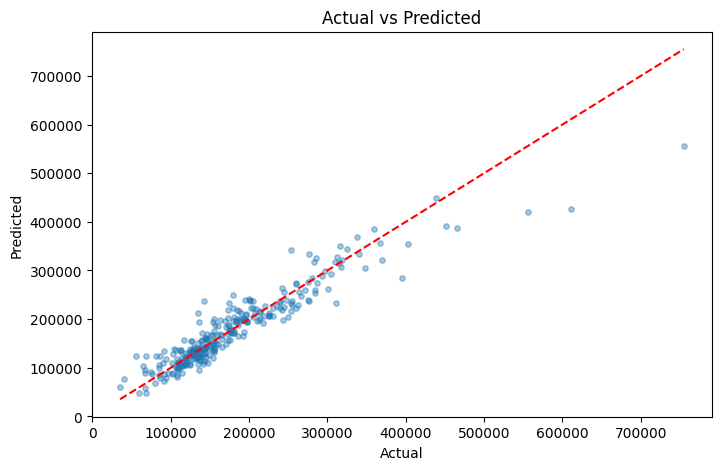

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#first fit the model on train data

model.fit(X_train, y_train)


#log the resulting model
mlflow.sklearn.log_model(model, "linear_regression_baseline")


#now predict on test data

y_pred = model.predict(X_test)


#now log the metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

mlflow.log_metric("test_rmse", test_rmse)
mlflow.log_metric("test_mae", test_mae)
mlflow.log_metric("test_r2", test_r2)

# let's also see how this predictions look visually

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, y_pred, alpha=0.4, s=15)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted')

mlflow.log_figure(fig, "actual_vs_predicted.png")



#### Check underfitting, overfitting

In [29]:
# we check the performance on train data, to see whether model overfits or not

train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")
print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")


print(f"if train RMSE is much lower than test RMSE, then we have overfitting. they differ by : {test_rmse - train_rmse}")


Train RMSE: 27969.750935100546
Test RMSE: 30691.226315053864
Train R2: 0.868840580167644
Test R2: 0.8771953959612249
if train RMSE is much lower than test RMSE, then we have overfitting. they differ by : 2721.4753799533173


#### Ending the run


In [30]:
mlflow.end_run()

🏃 View run linear_regression_baseline_model at: https://dagshub.com/gbera23-dev/Machine-Learning.mlflow/#/experiments/2/runs/0b1ae4196bb747128d665458741f5c50
🧪 View experiment at: https://dagshub.com/gbera23-dev/Machine-Learning.mlflow/#/experiments/2
